In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer

**Содержание**
1. [Подготовка данных](#Подготовка-данных)
2. [Анализ данных](#Анализ-данных)
3. [Модель](#Модель)
4. [Вывод](#Вывод)

# Восстановление золота из руды

Подготовьте прототип модели машинного обучения для «Цифры». Компания разрабатывает решения для эффективной работы промышленных предприятий.

Модель должна предсказать коэффициент восстановления золота из золотосодержащей руды. Используйте данные с параметрами добычи и очистки. 

Модель поможет оптимизировать производство, чтобы не запускать предприятие с убыточными характеристиками.

Вам нужно:

1. Подготовить данные;
2. Провести исследовательский анализ данных;
3. Построить и обучить модель.

Чтобы выполнить проект, обращайтесь к библиотекам *pandas*, *matplotlib* и *sklearn.* Вам поможет их документация.

## Подготовка данных

### Откроем файлы и изучим их.

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

test_frame = load_dataset('gold_recovery_test_new.csv')
train_frame = load_dataset('gold_recovery_train_new.csv')
full_frame = load_dataset('gold_recovery_full_new.csv')

In [3]:
train_frame.shape, test_frame.shape, full_frame.shape

((14149, 87), (5290, 53), (19439, 87))

In [4]:
train_frame.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [5]:
train_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 14149 entries, 0 to 14148
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                14149 non-null  str    
 1   final.output.concentrate_ag                         14148 non-null  float64
 2   final.output.concentrate_pb                         14148 non-null  float64
 3   final.output.concentrate_sol                        13938 non-null  float64
 4   final.output.concentrate_au                         14149 non-null  float64
 5   final.output.recovery                               14149 non-null  float64
 6   final.output.tail_ag                                14149 non-null  float64
 7   final.output.tail_pb                                14049 non-null  float64
 8   final.output.tail_sol                               14144 non-null  float64
 9   final.

In [6]:
train_frame.describe()

,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
count,14148.000000,14148.000000,13938.000000,14149.000000,14149.000000,14149.000000,14049.000000,14144.000000,14149.000000,14129.000000,...,14143.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14148.000000,14147.000000,14148.000000
mean,5.142034,10.132960,9.202849,44.003792,66.518832,9.607035,2.597298,10.512122,2.918421,133.320659,...,19.985454,-478.696836,15.487065,-460.229416,16.775136,-483.956022,13.064590,-483.966564,19.577539,-506.798480
std,1.369586,1.654930,2.790516,4.905261,10.295402,2.319069,0.971843,3.003617,0.903712,39.431659,...,5.657723,50.736021,5.255655,58.843586,5.831906,37.892788,5.765617,39.207913,5.764417,37.079249
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003112,...,0.000000,-799.709069,0.000000,-799.889113,-0.372054,-797.142475,0.646208,-800.006180,0.195324,-809.398668
25%,4.211620,9.297355,7.484645,43.276111,62.545817,7.997429,1.905973,8.811324,2.368607,107.006651,...,14.990775,-500.628656,11.894558,-500.149000,11.083980,-500.363177,8.994405,-500.105994,14.989304,-500.745104
50%,4.994652,10.297144,8.845462,44.872436,67.432775,9.480270,2.592022,10.514621,2.851025,133.018328,...,20.001789,-499.681450,14.975536,-499.388738,17.932223,-499.702452,11.997547,-499.914556,19.984175,-500.061431
75%,5.859540,11.170603,10.487508,46.166425,72.346428,11.003707,3.241723,11.933009,3.434764,159.825396,...,24.990826,-477.472413,20.059375,-400.039008,21.346550,-487.712108,17.982903,-453.186936,24.991623,-499.536466
max,16.001945,17.031899,18.124851,52.756638,100.000000,19.552149,5.639565,22.317730,8.197408,250.127834,...,30.115735,-245.239184,24.007913,-145.071088,43.709931,-275.073125,27.926001,-157.396071,32.188906,-104.427459


### Проверим, что эффективность обогащения рассчитана правильно. Вычислим её на обучающей выборке для признака rougher.output.recovery. Найдем MAE между нашими расчётами и значением признака.

In [7]:
C = 'rougher.output.concentrate_au'
F = 'rougher.input.feed_au'
T = 'rougher.output.tail_au'


def recovery(row):
    try:
        return row[C] * (row[F] - row[T]) / (row[F] * (row[C] - row[T])) * 100
    except ZeroDivisionError:
        return np.nan

In [8]:
train_frame = train_frame.dropna(subset=['rougher.output.recovery', 'final.output.recovery'])
train_frame['recovery'] = train_frame.apply(recovery, axis=1)
check_rows = train_frame[['recovery', 'rougher.output.recovery']].dropna()
mean_absolute_error(check_rows['recovery'], check_rows['rougher.output.recovery'])

9.73512347450521e-15

#### Вывод: 
Судя по малому размеру вычисленного MAE, эффективность обогащения на обучающей выборке для признака rougher.output.recovery рассчитана правильно

### Проанализируем признаки, недоступные в тестовой выборке

In [9]:
col_2  = [i for i in train_frame.columns if (i not in test_frame.columns)]

In [10]:
train_frame['rougher.calculation.floatbank10_sulfate_to_au_feed'].describe()

count     14148.000000
mean       3456.608298
std        5772.510248
min        -486.598675
25%        2527.093354
50%        2975.892211
75%        3716.360822
max      629638.977914
Name: rougher.calculation.floatbank10_sulfate_to_au_feed, dtype: float64

array([[<Axes: title={'center': 'final.output.concentrate_au'}>,
        <Axes: title={'center': 'final.output.tail_au'}>,
        <Axes: title={'center': 'primary_cleaner.output.concentrate_au'}>],
       [<Axes: title={'center': 'primary_cleaner.output.tail_au'}>,
        <Axes: title={'center': 'rougher.calculation.sulfate_to_au_concentrate'}>,
        <Axes: title={'center': 'rougher.calculation.floatbank10_sulfate_to_au_feed'}>],
       [<Axes: title={'center': 'rougher.calculation.floatbank11_sulfate_to_au_feed'}>,
        <Axes: title={'center': 'rougher.calculation.au_pb_ratio'}>,
        <Axes: title={'center': 'rougher.output.concentrate_au'}>],
       [<Axes: title={'center': 'rougher.output.tail_au'}>,
        <Axes: title={'center': 'secondary_cleaner.output.tail_au'}>,
        <Axes: >]], dtype=object)

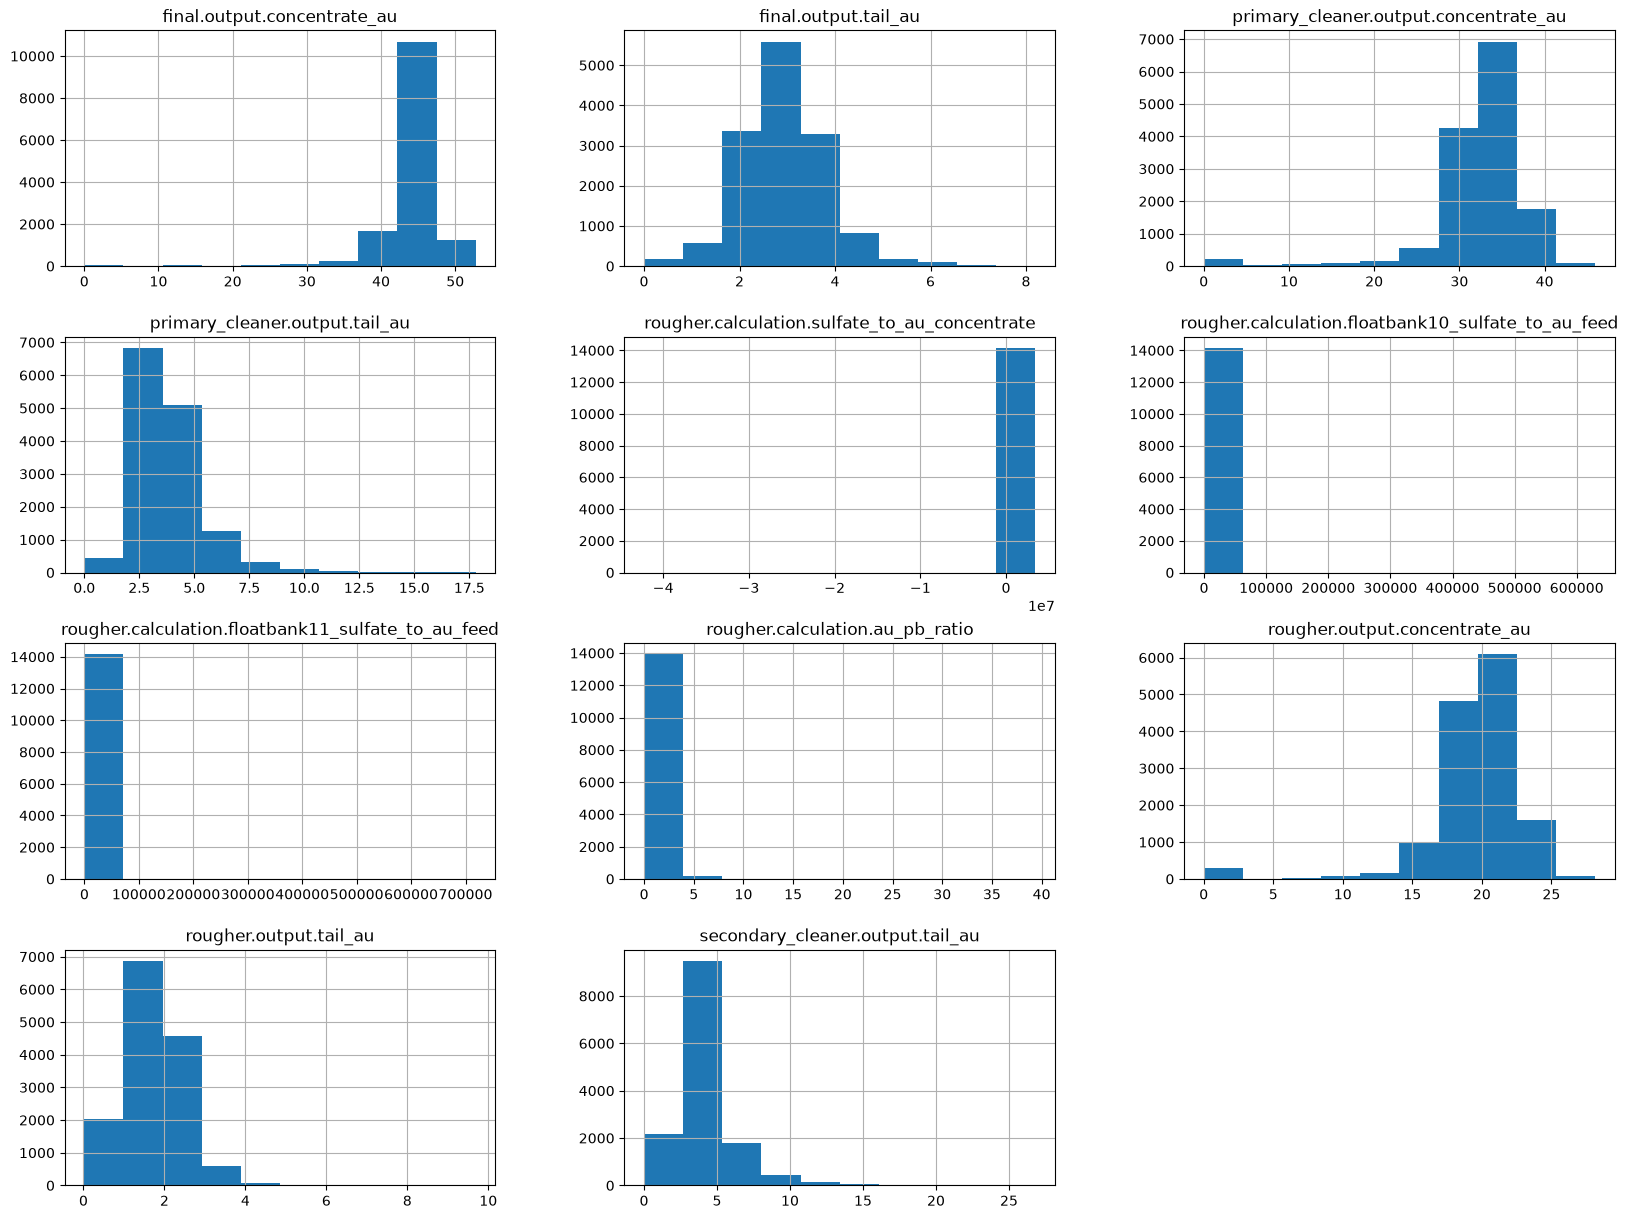

In [11]:
cols_au = [i for i in col_2 if '_au' in i or 'au_' in i]
train_frame[cols_au].hist(figsize=(20, 15), bins=10)

In [12]:
col_3 = ['final.output.recovery', 'rougher.output.recovery']

array([[<Axes: title={'center': 'final.output.recovery'}>,
        <Axes: title={'center': 'rougher.output.recovery'}>]],
      dtype=object)

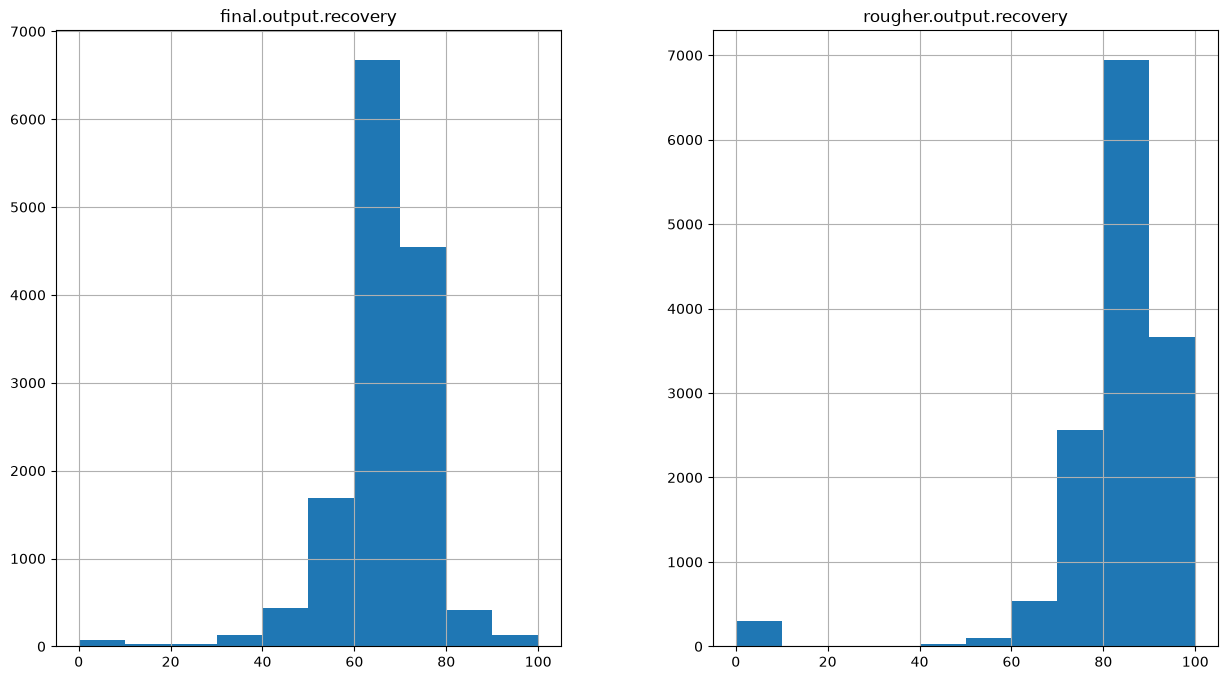

In [13]:
train_frame[col_3].hist(figsize=(15,8), bins=10)

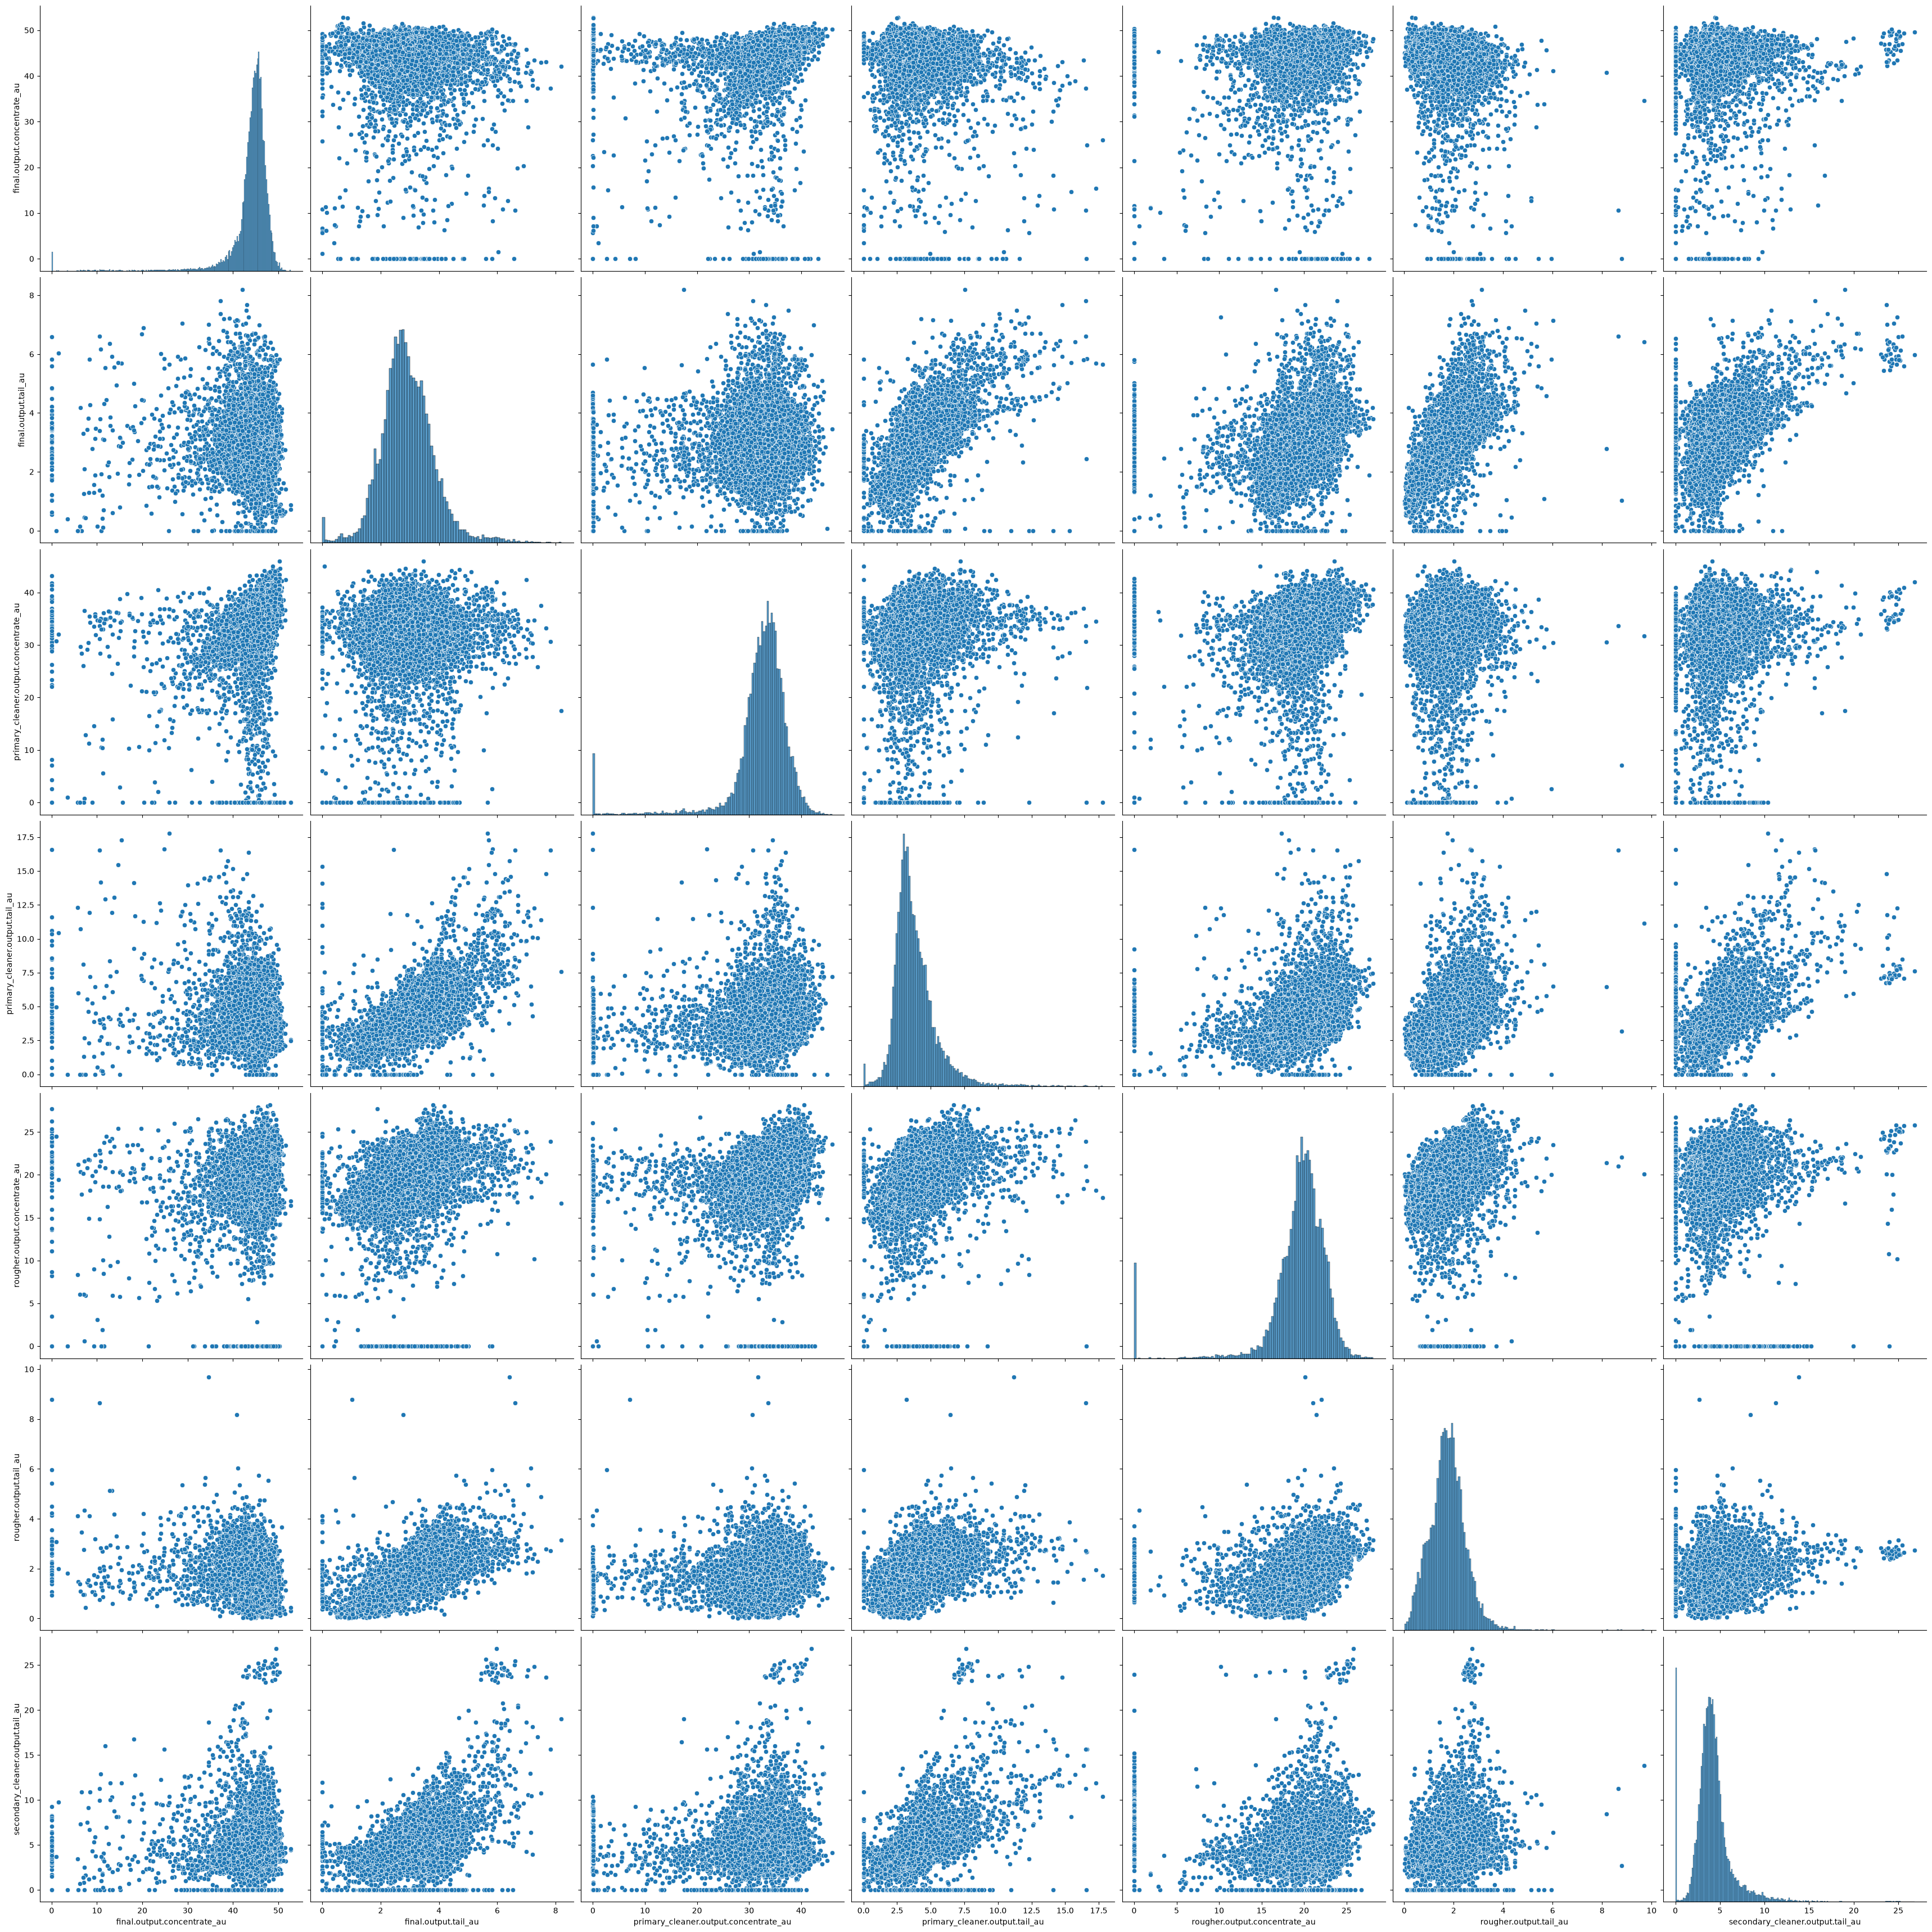

In [14]:
sns.pairplot(train_frame[['final.output.concentrate_au',
 'final.output.tail_au',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_au',
 'rougher.output.concentrate_au',
 'rougher.output.tail_au',
 'secondary_cleaner.output.tail_au']], height=5)

<Axes: >

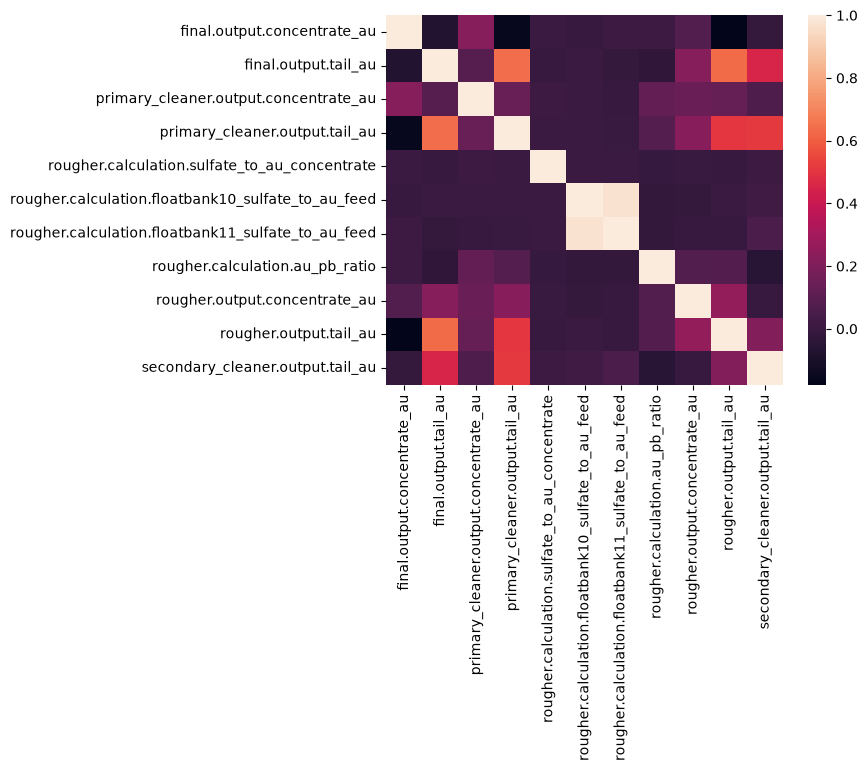

In [15]:
sns.heatmap(train_frame[cols_au].corr())

#### Вывод:
Недоступные в тестовой выборке признаки описывают параметры продукта и расчётные характеристики для следующих этапов: флотация и первичная, вторичная очистки и финальные характеристики 

### Проведем предобработку данных.

In [16]:
train_frame = train_frame.bfill()
test_frame = test_frame.bfill()
full_frame = full_frame.bfill()

In [17]:
train_frame = train_frame.dropna()
test_frame = test_frame.dropna()
full_frame = full_frame.dropna()

Поиск пропусков:

In [18]:
train_frame[train_frame.isnull()==True].count().sum(),test_frame[test_frame.isnull()==True].count().sum(), full_frame[full_frame.isnull()==True].count().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [19]:
train_frame.shape, test_frame.shape, full_frame.shape

((14149, 88), (5290, 53), (19439, 87))

## Анализ данных

### Посмотрим, как меняется концентрация металлов (Au, Ag, Pb) на различных этапах очистки. 

ougher.input.feed_…, rougher.output.concentrate_…, primary_cleaner.output.concentrate_…, final.output.concentrate_… - это всё концентрации.

Лучше всего строить графики для этих 4-ех типов концентраций для каждого отдельного металла на одном графике. Так будет наиболее информативно

<Axes: title={'center': 'Зависимость концентрации золота от этапа очистки'}>

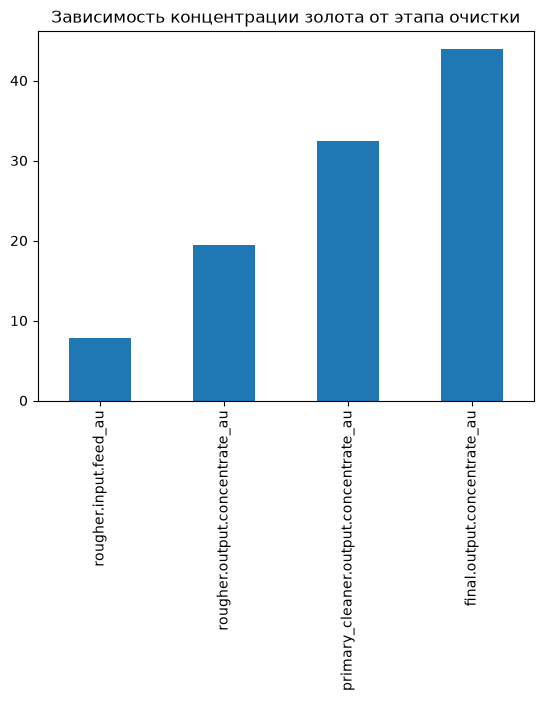

In [20]:
train_frame[['rougher.input.feed_au', 'rougher.output.concentrate_au',
             'primary_cleaner.output.concentrate_au',
             'final.output.concentrate_au' ]].agg(np.mean).plot(kind='bar', title='Зависимость концентрации золота от этапа очистки')

<Axes: title={'center': 'Зависимость концентрации серебра от этапа очистки'}>

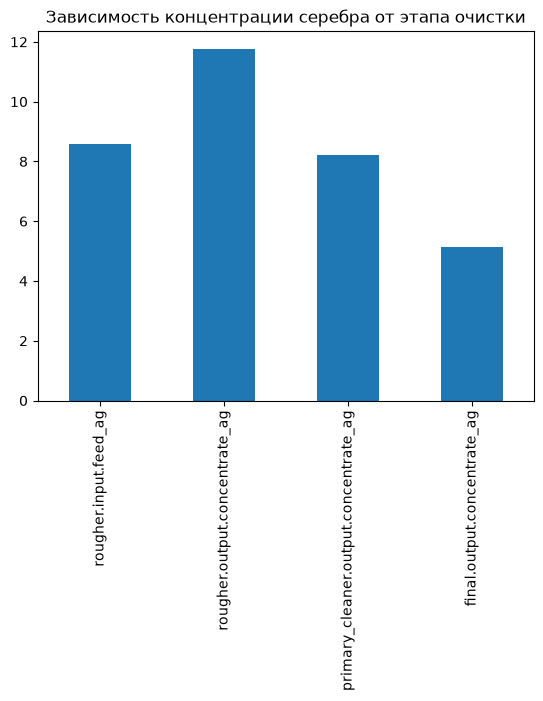

In [21]:
train_frame[['rougher.input.feed_ag', 'rougher.output.concentrate_ag',
             'primary_cleaner.output.concentrate_ag',
             'final.output.concentrate_ag' ]].agg(np.mean).plot(kind='bar', title='Зависимость концентрации серебра от этапа очистки')

<Axes: title={'center': 'Зависимость концентрации свинца от этапа очистки'}>

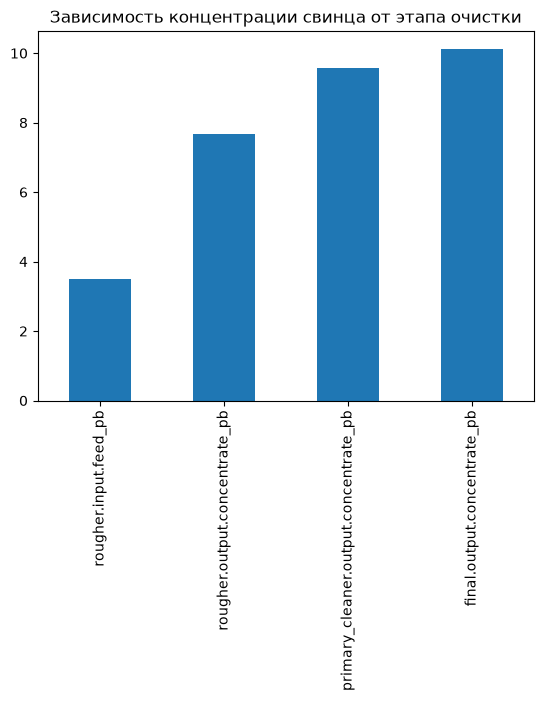

In [22]:
train_frame[['rougher.input.feed_pb', 'rougher.output.concentrate_pb',
             'primary_cleaner.output.concentrate_pb',
             'final.output.concentrate_pb' ]].agg(np.mean).plot(kind='bar', title='Зависимость концентрации свинца от этапа очистки')

### Сравним распределения размеров гранул сырья на обучающей и тестовой выборках. Если распределения сильно отличаются друг от друга, оценка модели будет неправильной.

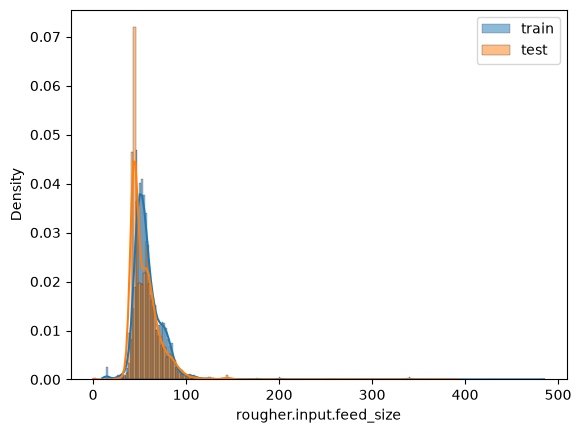

In [23]:
sns.histplot(train_frame['rougher.input.feed_size'], kde=True, stat='density', label='train', color='tab:blue')
sns.histplot(test_frame['rougher.input.feed_size'], kde=True, stat='density', label='test', color='tab:orange')
plt.legend()
plt.show()

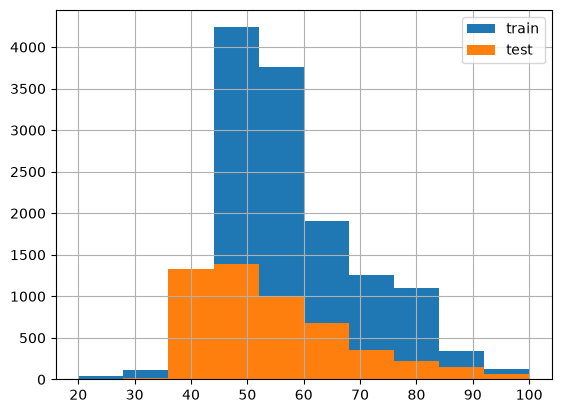

In [24]:
train_frame['rougher.input.feed_size'].hist(range = (20, 100), bins=10)
test_frame['rougher.input.feed_size'].hist(range = (20, 100), bins=10)
plt.legend(['train', 'test'])
plt.show()

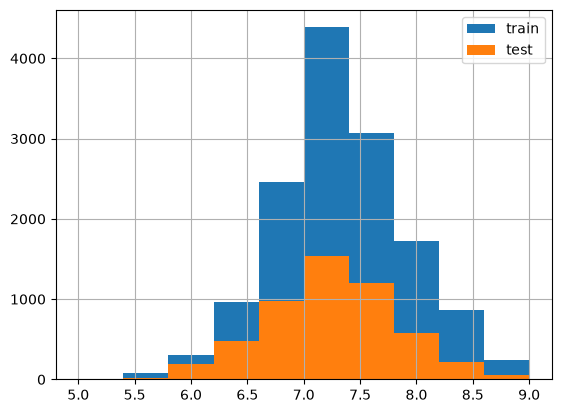

In [25]:
train_frame['primary_cleaner.input.feed_size'].hist(range = (5, 9), bins=10)
test_frame['primary_cleaner.input.feed_size'].hist(range = (5, 9), bins=10)
plt.legend(['train', 'test'])
plt.show()

#### Вывод: распределения не сильно отличаются друг от друга

### Исследуем суммарную концентрацию всех веществ на разных стадиях: в сырье, в черновом и финальном концентратах.

In [26]:
rougher_cols = ['rougher.input.feed_pb', 'rougher.input.feed_ag', 'rougher.input.feed_au', 'rougher.input.feed_sol']
train_frame['rougher_sum'] = train_frame[rougher_cols].sum(axis=1)
train_frame['rougher_sum'].describe()

count    14149.000000
mean        56.235165
std          7.044797
min          0.040000
25%         52.566699
50%         56.616769
75%         60.771094
max         74.458253
Name: rougher_sum, dtype: float64

In [27]:
train_frame['rougher_sum'].quantile(0.001)

np.float64(14.979097846285878)

In [28]:

train_frame = train_frame.drop(train_frame[train_frame['rougher_sum']<=train_frame['rougher_sum'].quantile(0.001)].index)

In [29]:
conc_cols = ['rougher.output.concentrate_pb', 'rougher.output.concentrate_ag',
             'rougher.output.concentrate_au', 'rougher.output.concentrate_sol']
train_frame['conc_sum'] = train_frame[conc_cols].sum(axis=1)
train_frame['conc_sum'].describe()

count    14134.000000
mean        67.245551
std         12.555796
min          0.000000
25%         64.935818
50%         69.183622
75%         73.435011
max         88.140119
Name: conc_sum, dtype: float64

In [30]:
train_frame['conc_sum'].quantile(0.001)

np.float64(0.0)

In [31]:
train_frame = train_frame.drop(train_frame[train_frame['conc_sum']<=train_frame['conc_sum'].quantile(0.001)].index)

In [32]:
final_cols = ['final.output.concentrate_pb', 'final.output.concentrate_ag',
              'final.output.concentrate_au', 'final.output.concentrate_sol']
train_frame['final_sum'] = train_frame[final_cols].sum(axis=1)
train_frame['final_sum'].describe()

count    13839.000000
mean        68.420502
std          6.885500
min          0.000000
25%         67.548421
50%         69.133481
75%         70.949354
max         80.210644
Name: final_sum, dtype: float64

In [33]:
train_frame['final_sum'].quantile(0.001)

np.float64(0.0)

In [34]:
train_frame = train_frame.drop(train_frame[train_frame['final_sum']<=train_frame['final_sum'].quantile(0.001)].index)

In [35]:
# делим трейн на признаки и таргеты
train_features = train_frame[test_frame.columns].drop(['date'], axis=1)
train_target = train_frame[['rougher.output.recovery', 'final.output.recovery']]
# таргеты теста по условию задачи подтягиваем из полного датасета по дате
targets_to_join = full_frame[['date', 'rougher.output.recovery', 'final.output.recovery']].copy()
test_frame = test_frame.join(targets_to_join.set_index('date'), on='date')
test_frame = test_frame.dropna(subset=['rougher.output.recovery', 'final.output.recovery'])
test_features = test_frame.drop(['date', 'rougher.output.recovery', 'final.output.recovery'], axis=1)
test_target = test_frame[['rougher.output.recovery', 'final.output.recovery']]
test_frame.head()

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,rougher.output.recovery,final.output.recovery
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414,89.993421,70.273583
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438,88.089657,68.910432
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559,88.412756,68.143213
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987,87.360133,67.776393
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333,83.236367,61.467078


In [36]:
test_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 5290 entries, 0 to 5289
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rougher.output.recovery  5290 non-null   float64
 1   final.output.recovery    5290 non-null   float64
dtypes: float64(2)
memory usage: 82.8 KB


In [37]:
#масштабируем фичи на трейне и на тесте
scaler = StandardScaler()
scaler.fit(train_features)
train_features[train_features.columns] = scaler.transform(train_features[train_features.columns])
test_features[test_features.columns] = scaler.transform(test_features[test_features.columns])

In [38]:
train_features.shape, test_features.shape

((13782, 52), (5290, 52))

## Модель

### Напишем функцию для вычисления итоговой sMAPE

In [39]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    error = np.abs(y_true - y_pred)
    scale = (np.abs(y_true) + np.abs(y_pred)) / 2
    return (error / scale).mean() * 100


def smape_weighted(y_true, y_pred):
    y_true = pd.DataFrame(y_true).reset_index(drop=True)
    y_pred = pd.DataFrame(data=np.asarray(y_pred))
    rougher = smape(y_true.iloc[:, 0], y_pred.iloc[:, 0])
    final = smape(y_true.iloc[:, 1], y_pred.iloc[:, 1])
    return 0.25 * rougher + 0.75 * final

### Обучим разные модели и оценим их качество кросс-валидацией. Выберем лучшую модель и проверим её на тестовой выборке. Опишем выводы.

Метрика задачи — взвешенный sMAPE: `0.25 * sMAPE(rougher) + 0.75 * sMAPE(final)`.

Сравнение моделей проводим **кросс-валидацией на обучающей выборке** (для каждого таргета обучается отдельная модель), а тестовую выборку используем один раз — для финальной оценки лучшей модели. Так мы не подгоняем выбор модели под тест.

In [40]:
smape_scorer = make_scorer(smape, greater_is_better=False)


def cv_smape(model, X, y, cv=3):
    """Взвешенный sMAPE по кросс-валидации: отдельные модели для rougher и final."""
    score_r = -cross_val_score(clone(model), X, y.iloc[:, 0], cv=cv, scoring=smape_scorer).mean()
    score_f = -cross_val_score(clone(model), X, y.iloc[:, 1], cv=cv, scoring=smape_scorer).mean()
    return 0.25 * score_r + 0.75 * score_f

In [41]:
%%time
candidates = {
    'DummyRegressor (median)': DummyRegressor(strategy='median'),
    'LinearRegression': LinearRegression(),
    'RandomForest (max_depth=5)': RandomForestRegressor(random_state=12345, max_depth=5, n_jobs=4),
    'RandomForest (max_depth=10)': RandomForestRegressor(random_state=12345, max_depth=10, n_jobs=4),
    'Bagging (DecisionTree, 20)': BaggingRegressor(DecisionTreeRegressor(random_state=12345),
                                                   n_estimators=20, random_state=12345, n_jobs=4),
}
cv_results = {}
for name, model in candidates.items():
    cv_results[name] = cv_smape(model, train_features, train_target)
    print('{:<30} CV sMAPE = {:.3f}'.format(name, cv_results[name]))

DummyRegressor (median)        CV sMAPE = 10.298
LinearRegression               CV sMAPE = 12.658


RandomForest (max_depth=5)     CV sMAPE = 10.100


RandomForest (max_depth=10)    CV sMAPE = 9.896


Bagging (DecisionTree, 20)     CV sMAPE = 10.485
CPU times: user 2min 23s, sys: 213 ms, total: 2min 23s
Wall time: 46.9 s


### Финальная проверка лучшей модели на тестовой выборке

In [42]:
def test_smape(model):
    """Обучает по отдельной модели на каждый таргет и считает взвешенный sMAPE на тесте."""
    model_r = clone(model).fit(train_features, train_target.iloc[:, 0])
    model_f = clone(model).fit(train_features, train_target.iloc[:, 1])
    smape_r = smape(test_target.iloc[:, 0], model_r.predict(test_features))
    smape_f = smape(test_target.iloc[:, 1], model_f.predict(test_features))
    return 0.25 * smape_r + 0.75 * smape_f


best_name = min(cv_results, key=cv_results.get)
best_model = candidates[best_name]
print('Лучшая модель по кросс-валидации:', best_name)
print('sMAPE лучшей модели на тестовой выборке: {:.3f}'.format(test_smape(best_model)))
print('sMAPE константной модели (медиана) на тестовой выборке: {:.3f}'.format(
    test_smape(DummyRegressor(strategy='median'))))

Лучшая модель по кросс-валидации: RandomForest (max_depth=10)


sMAPE лучшей модели на тестовой выборке: 9.245
sMAPE константной модели (медиана) на тестовой выборке: 9.440


## Вывод
Проверена формула эффективности обогащения (MAE между расчётом и признаком ≈ 10⁻¹⁴), проведён анализ концентраций металлов по этапам очистки, сопоставлены распределения размеров гранул в train/test, удалены аномалии по суммарным концентрациям.

Модели сравнивались кросс-валидацией на обучающей выборке по взвешенному sMAPE (0.25 × rougher + 0.75 × final):

| Модель | CV sMAPE |
|---|---|
| DummyRegressor (медиана) | 10.30 |
| LinearRegression | 12.66 |
| RandomForest (max_depth=5) | 10.10 |
| **RandomForest (max_depth=10)** | **9.90** |
| Bagging (DecisionTree, 20) | 10.49 |

Лучшая модель — **RandomForest (max_depth=10)**: на тестовой выборке **sMAPE = 9.25** против 9.44 у константной модели. Модель превосходит baseline, но выигрыш умеренный: признаки процесса объясняют лишь часть дисперсии recovery. Возможные направления улучшения — генерация признаков по стадиям процесса, градиентный бустинг, учёт временной структуры данных.